# I) Questions de cours

1.) Quelle est la principale différence entre la classification et la régression?

- Réponse: La classification et le régression sont des méthodes d'apprentissage supervisés qui se différencient par le fait que la variable réponse est qualitative en classification et quantitative en régression

2.) Quelle est la principale différence entre le clustering (partitionnement) et la classification?


- Réponse: Le clustering est une méthode d'apprentissage NON supervisé (où on cherche à partitionner les observations d'une variable $X$ dans des groupes les plus homogènes possibles) contrairement à la classification (méthode supervisée) qui cherche à prédire l'appartenance d'une observation de $X$ à un groupe déjà défini par une variable $Y$

3.)  On se place dans le cas d’une population sur laquelle est définie une partition en $K = 2$ groupes, notés $G_1$ et $G_2$. Les proportions théoriques de ces deux groupes sont respectivement $p_1$ et $p_2$. On suppose que la distribution de probabilité d’une observation
$X = (X_1,X_2)$ est donnée pour chaque groupe  par une distribution de probabilité normale $N(\mu_k,\Sigma)$.  On considère la règle qui consiste à affecter une nouvelle observation $x$ au
groupe $G_k$ si
$\delta_k(x) = x^T \Sigma^{-1} \mu_k - \frac{1}{2} \mu_k^T \Sigma^{-1} \mu_k + \log p_k$
est maximale.

  a) Quel est le nom de cette règle ?
   - Réponse: LDA
   
  b) On a appliqué cette règle sur un jeu de données de taille $n = 125$ avec $n_1 = 30$ observations dans $G_1$ et $n_2 = 95$ observations dans $G_2$. On suppose que les probabilitès $p_1$ et $p_2$ ont été estimées par les proportions des groupes. On obtient les résultats suivants: 23 des individus de $G_1$ ont été correctement prédits et 91 des individus de $G_2$ ont été  bien classés. Donnez le pourcentage d'individus de $G_1$ et le pourcentage d’individus du groupe $G_2$ qui ont été mal classés.
  
   - Le pourcentage d'individus de $G_1$ mal classés est
   $$
   1-\hat{p}_1=1-\frac{23}{30}=\frac{7}{30}
   $$
   
    - Le pourcentage d'individus de $G_1$ mal classés est
   $$
   1-\hat{p}_2=1-\frac{91}{95}=\frac{4}{95}
   $$

4.) Supposons que la propension $Y^*_i$  à rembourser un crédit d'un l'individu $i$ ne dépende que de son statut familial décrit par 3 modalités :
 - célibataire :$X=1$
 - marié : $X=2$
 - autre : $X=3$



Est-ce-qu'un modèle modèle latent sous la forme :
$$Y^* = \beta_0 + \beta_1 X + u$$
a un sens?

- Réponse:

Ce modèle n'a pas de sens, en effet, cela voudrat dire:

   - célibataire :  $Y^*_C = \beta_0 + \beta_1  + u$
   - marié :  $Y^*_M = \beta_0 + 2 \beta_1  + u$
   - autre :  $Y^*_A = \beta_0 + 3 \beta_1 + u$


On aurait donc $Y^*_A - Y^*_M = Y^*_M - Y^*_C$. Cette contrainte est difficile à interpréter et à justifier.


On définit plutôt une variable binaire pour chacune des modalités :


   - $I_C$ : $I_C = 1$, si l'individu est célibataire, 0 sinon

   - $I_M$ : $I_M = 1$, si l'individu est marié, 0 sinon
   
   - $I_A$ : $I_A = 1$, si l'individu est autre, 0 sinon

On remarque que, pour tout individu, $I_C + I_M + I_A = 1$. Les 3 variables binaires sont linéairement dépendantes. On ne pourra donc pas les intégrer dans le modèle si on souhaite y maintenir un terme constant.

5.) Soit


- $Y_i$ =  1 si l'individu $i$ est bon payeur
- $Y_i$ =  0 si l'individu $i$ est mauvais payeur



On a établi un score $S$, fonction des caractéristiques $X_i$ de l'individu $i$, avec lequel on calcule la prévision $\widehat{Y}_i$ :

$$\widehat Y_i (X_i)  = \left\{ \begin{array}{l}  1 \mbox{ si } S(X_i)>s\\
  0 \mbox{ si } S(X_i) <s \end{array} \right.$$

Le nombre d'individus pour lesquels $\widehat Y_i (X_i) = 1$, c'est-à-dire le nombre d'individus qu'on prédit être des bons payeurs, va dépendre de la valeur retenue pour le seuil $s$.
Les logiciels adoptent souvent la règle de prévision suivante :
$$\widehat Y_i (X_i)  = \left\{ \begin{array}{l}  1 \mbox{ si } \hat P[Y=1 \mid X_i]>0.5\\
  0 \mbox{ si } \hat P[Y=1 \mid X_i]\leq0.5 \end{array} \right.$$

Autrement dit, un individu est prédit comme bon payeur si le modèle prédit qu'il a plus d'une chance sur deux de l'être.

Cela correspondant à un choix de seuil très particulier.
Si on considère un modèle LOGIT
$$ P[Y=1 \mid X_i]= \frac{1}{1 + \exp ^{-X_i \theta}}$$
à quoi correspond le choix du seuil

 - Réponse
 $$ P[Y=1 \mid X_i]= \frac{1}{1 + \exp ^{-X_i \theta}}>0.5 \Rightarrow \frac{1}{1 + \exp ^{-X_i \theta}} > 0.5,\;  \Rightarrow \exp ^{-X_i \theta} < 1 \Rightarrow X_i \theta > 0$$


# II) Mise en pratique

## 1) Faites une étude statistique exploratoire des données, fournissez quelques tableaux synthétiques

In [10]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
import pandas as pd
import numpy as np
pd.plotting.register_matplotlib_converters()
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from scipy.stats import pearsonr

# Importation des données
CRSC_data = pd.read_csv("../../data/CRSC.csv", sep=";")


CRSC_data.head()

,Obs,Y,AGE,NCARTES,PROP,PROF
0,1,1,49,16,0,5
1,2,1,57,5,0,6
2,3,0,37,1,0,5
3,4,0,44,1,0,2
4,5,1,60,9,1,7


In [11]:
CRSC_data = CRSC_data.drop('Obs', axis =1);
CRSC_data.head()

,Y,AGE,NCARTES,PROP,PROF
0,1,49,16,0,5
1,1,57,5,0,6
2,0,37,1,0,5
3,0,44,1,0,2
4,1,60,9,1,7


In [ ]:

#### Quelques tableaux synthétiques

CRSC_data['PROP'] = CRSC_data['PROP'].astype('category')
CRSC_data['PROF'] = CRSC_data['PROF'].astype('category')
CRSC_data1=CRSC_data
CRSC_data['Y'] = CRSC_data['Y'].astype('category')

CRSC_data.head()
#CRSC_data.describe()

,AGE,NCARTES
count,950.000000,950.000000
mean,44.865263,2.615789
std,8.058058,2.709847
min,18.000000,0.000000
25%,39.000000,1.000000
50%,45.000000,2.000000
75%,51.000000,4.000000
max,69.000000,18.000000


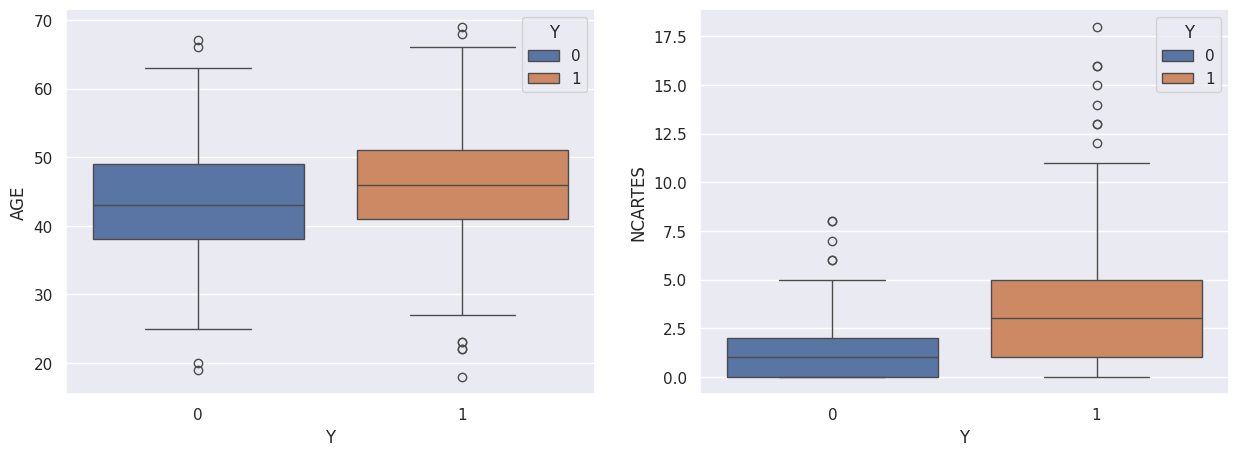

In [13]:
fig,axs = plt.subplots(1,2,figsize = (15,5))
plt.subplot(1,2,1)
sns.boxplot(x='Y',y='AGE',hue="Y",data=CRSC_data)
sns.set(rc = {'figure.figsize':(5,5)})

plt.subplot(1,2,2)
sns.boxplot(x='Y',y='NCARTES',hue="Y",data=CRSC_data)
sns.set(rc = {'figure.figsize':(5,5)})


In [14]:
print(pd.crosstab(CRSC_data['Y'], CRSC_data['PROF']))


PROF   1   2    3   4    5   6   7   8
Y                                     
0     42  60   45  37   79  59   9  76
1     44  45  124  53  154  77  20  26


In [15]:
print(pd.crosstab(CRSC_data['Y'], CRSC_data['PROP']))

PROP    0    1
Y             
0     386   21
1     363  180


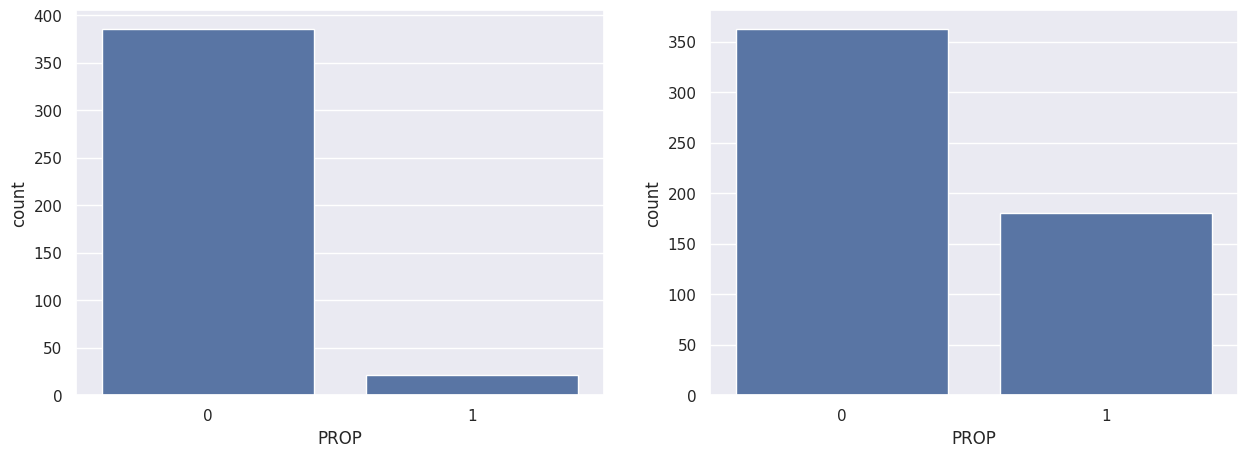

In [16]:

CRSC_data_Y0 = CRSC_data[CRSC_data['Y']==0]
CRSC_data_Y1 = CRSC_data[CRSC_data['Y']==1]


fig,axs = plt.subplots(1,2,figsize = (15,5))

plt.subplot(1,2,1)
sns.countplot(data=CRSC_data_Y0, x='PROP')
sns.set(rc = {'figure.figsize':(5,5)})

plt.subplot(1,2,2)
sns.countplot(data=CRSC_data_Y1, x='PROP')
sns.set(rc = {'figure.figsize':(5,5)})

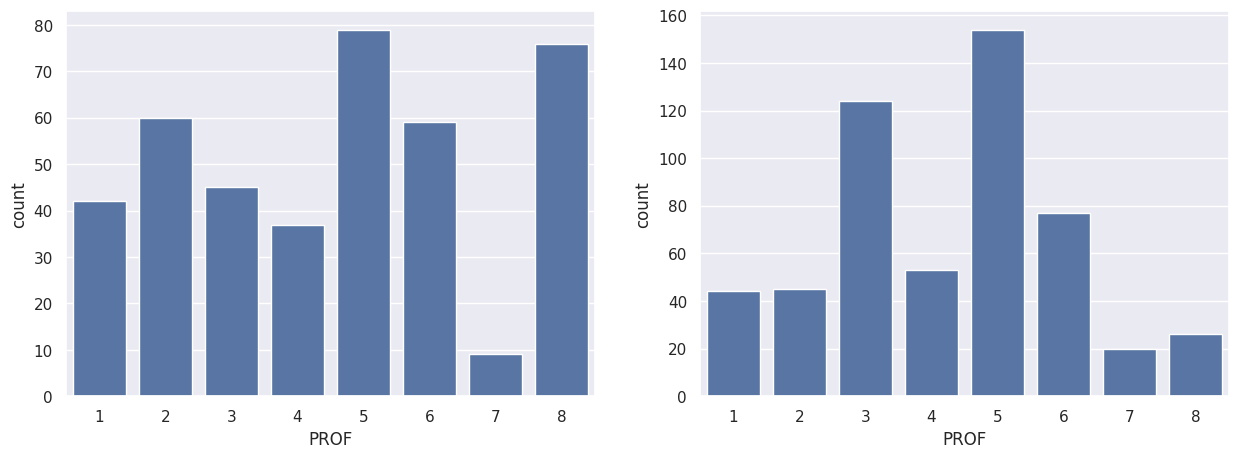

In [17]:

fig,axs = plt.subplots(1,2,figsize = (15,5))
plt.subplot(1,2,1)
sns.countplot(data=CRSC_data_Y0, x='PROF')
sns.set(rc = {'figure.figsize':(5,5)})
plt.subplot(1,2,2)
sns.countplot(data=CRSC_data_Y1, x='PROF')
sns.set(rc = {'figure.figsize':(5,5)})

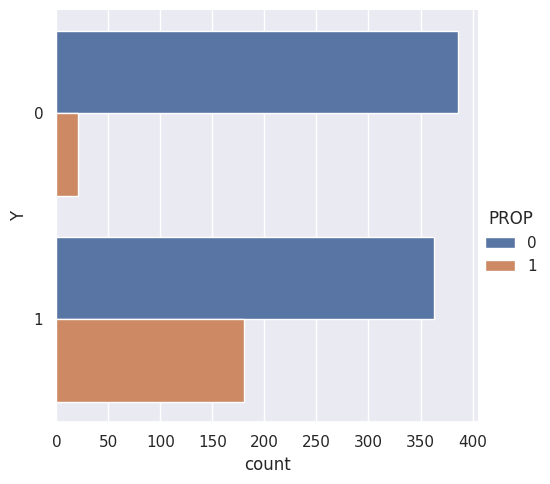

In [18]:
sns.catplot(
    data=CRSC_data, y="Y", hue="PROP", kind="count"
)

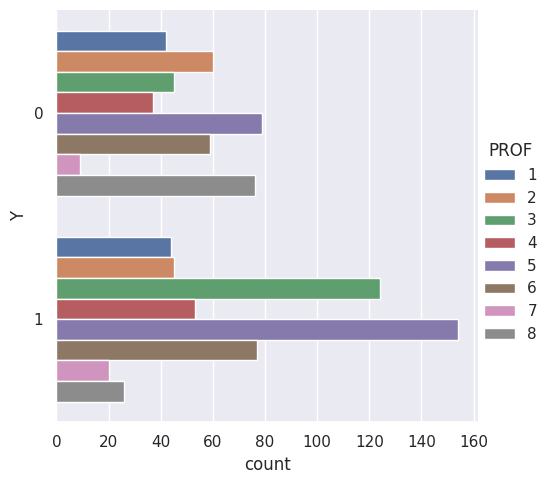

In [19]:
sns.catplot(
    data=CRSC_data, y="Y", hue="PROF", kind="count"
)

## 2) Y a t-il des écarts significatifs entre les bons payeurs et les mauvais payeurs en ce qui concerne :
(a) leur âge moyen ?
(b) leur statut de propriétaire ou non ?

### a) Age

In [22]:
from scipy.stats import ttest_ind

# Effectuer le test de Student indépendant
statistic, p_value = ttest_ind(CRSC_data_Y0['AGE'], CRSC_data_Y1['AGE'])

# Afficher les résultats
print("Statistic:", statistic)
print("P-value:", p_value)

# Interpréter le résultat
if p_value < 0.05:
    print("La différence entre les moyennes d'age dans les deux groupes est statistiquement significative.")
else:
    print("Il n'y a pas de différence statistiquement significative entre les moyennes d'age dans les deux groupes.")


Statistic: -4.97690855464466
P-value: 7.671260615561592e-07
La différence entre les moyennes d'age dans les deux groupes est statistiquement significative.


Sous l'hypothèse d'égalite des variances (à vérifier en pratique), il y a un écart significatif (avec un seuil de 5%) entre la moyenne d’âge des bons payeurs (45,98) et celle des mauvais payeurs (43,38) ; donc l’âge serait un facteur assez significatif dans la détermination de la qualité du client.

### b) Statut de propriètaire

In [ ]:
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

# Z-test pour proportion

effectifs = np.array([
    len(CRSC_data_Y0[CRSC_data_Y0['PROP'] == 1]),
    len(CRSC_data_Y1[CRSC_data_Y1['PROP'] == 1])
])

nobs = np.array([len(CRSC_data_Y0), len(CRSC_data_Y1)])

# Effectuer le test Z pour proportions
statistic, p_value = proportions_ztest(effectifs, nobs)

# Afficher les valeurs
print(f'Z-statistic = {statistic:.3f}; p = {p_value:.3f}')
print("Statistic:", statistic)
print("P-value:", p_value)


# Interpréter le résultat
if p_value < 0.05:
    print("La différence entre les proportions de proprietaires dans les deux groupes est statistiquement significative.")
else:
    print("Il n'y a pas de différence statistiquement significative entre les proportions de proprietaires dans les deux groupes.")


ModuleNotFoundError: No module named 'statsmodels'

In [ ]:
effectifs/nobs

array([0.05159705, 0.33149171])

La proportion d'individus propriétaires parmi les bons payeurs (0,33) est significativement plus élevée (environ 6,6 fois) que celle parmi les mauvais payeurs (0,05). Ainsi, être propriétaire augmente considérablement les chances d'être un bon payeur.

##  3) Rédigez une brève note à destination du directeur commercial de l’organisme de crédit XX pour mettre en évidence les points les plus pertinents de votre travail. N’oubliez pas que le directeur commercial ne connaît rien en statistique...


Au terme de l'étude statistique exploratoire portant sur un échantillon de 950 observations pour évaluer les caractéristiques des bons et mauvais payeurs, plusieurs conclusions peuvent être tirées :
- Une différence significative d'âge entre les bons et mauvais payeurs est observée, suggérant une influence de cette variable sur la qualité du client. Ainsi, il est judicieux d'inclure cette variable dans le modèle à construire ultérieurement.
- Certaines professions, telles que la catégorie "autre", sont plus fréquentes parmi les mauvais payeurs, tandis que les cadres sont plus représentés parmi les bons payeurs.
- Les propriétaires ont une probabilité plus élevée d'être des bons payeurs par rapport aux non-propriétaires, avec une proportion de bons payeurs de 89.5% contre 48,4% chez les non-propriétaires.
- Les mauvais payeurs sont plus susceptibles de ne pas détenir de cartes ou de produits bancaires, avec une proportion de 15,68% ne détenant aucun produit bancaire, contre seulement 8% chez les bons payeurs. De plus, la moyenne des produits bancaires détenus par un bon payeur est plus du double de celle d'un mauvais payeur. Il est donc envisageable que la qualité du client soit expliquée par les variables suivantes dans un modèle : l'âge, le statut de propriétaire, la profession et le nombre de cartes détenues.

## 4) Estimez un modèle LOGIT avec l’âge (et une constante) comme seule variable explicative. Interprétez les résultats.

In [ ]:

# Modélisation de la probabilité que l'individu soit un bon payeur P(Y=1)
import pandas as pd
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_scorefrom sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score


logit_model = sm.Logit(CRSC_data['Y'], sm.add_constant(CRSC_data['AGE']))
logit_results = logit_model.fit()
print(logit_results.summary())


logit_model = sm.Logit(CRSC_data['Y'], sm.add_constant(CRSC_data['AGE']))
logit_results = logit_model.fit()
print(logit_results.summary())


Optimization terminated successfully.
         Current function value: 0.669977
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      948
Method:                           MLE   Df Model:                            1
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                 0.01887
Time:                        10:07:32   Log-Likelihood:                -636.48
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                 7.482e-07
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.5458      0.382     -4.046      0.000      -2.295      -0.797
AGE            0.0410      0.

L’estimation par  maximum de vraisemblance révèle que tous les
paramètres du modèle $Y= \beta_0 + \beta_1 Age$ sont significatifs ; leur ‘’pvalue’’ étant
inférieure au seuil de 5%. Le coefficient de l'age étant positif, les plus personnes les plus agèes seraient moins risquées, cependant le coefficient est proche de 0.

#### OU

In [ ]:
from sklearn.linear_model import LinearRegression
from scipy.stats import t

def logitstatvals(X,y,sigfig):

    logreg = LogisticRegression(random_state=0)
    logreg.fit(X,np.ravel(y))
    y_pred = logreg.predict_proba(X)
    inter = logreg.intercept_
    coeffs = logreg.coef_
    coeffs = coeffs.T

    X_design = np.hstack([np.ones((X.shape[0], 1)), X])
    V = np.diagflat(np.product(y_pred,axis = 1))
    covar = np.linalg.inv(X_design.T @ V @ X_design)

    sterrs = np.sqrt(np.diag(covar))

    z_b0 = inter/sterrs[0]
    z_b1 = coeffs.T/sterrs[1:]
    z_b1 = z_b1.T

    dof = np.shape(X)[0]-2
    pval_0 = 2*(1 - t.cdf(abs(z_b0), dof))
    pval_1 = 2*(1 - t.cdf(abs(z_b1), dof))
    pval_1 = np.array(pval_1)

    d = {0: ["Intercept", inter, sterrs[0], z_b0, pval_0]}
    for i in range(0,len(sterrs)-1):
        d[i+1] = [X.columns[i], coeffs[i], sterrs[1+i],z_b1[i],pval_1[i]]
    print ("{:<12} {:<12} {:<12} {:<12} {:<12}".format("Parameter",'Coefficient','Std. Error','z-statistic','p-value'))
    for k, v in d.items():
        name, coef,std,tstat,pval = v
        print ("{:<12} {:<12} {:<12} {:<12} {:<12}".format(name,round(float(coef),sigfig),round(float(std),sigfig),round(float(tstat),sigfig),round(float(pval),sigfig)))



In [ ]:
X = CRSC_data[['AGE']]

y = CRSC_data[['Y']]

logitstatvals(X,y,5)

Parameter    Coefficient  Std. Error   z-statistic  p-value     
Intercept    -1.54563     0.38205      -4.04557     6e-05       
AGE          0.04104      0.00845      4.85565      0.0         


<ipython-input-15-f5385fb232c4>:5: DeprecationWarning: `product` is deprecated as of NumPy 1.25.0, and will be removed in NumPy 2.0. Please use `prod` instead.
  logitstatvals(X,y,5)
<ipython-input-14-1d1229eda87b>:34: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print ("{:<12} {:<12} {:<12} {:<12} {:<12}".format(name,round(float(coef),sigfig),round(float(std),sigfig),round(float(tstat),sigfig),round(float(pval),sigfig)))


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

thres = np.linspace(0,1,100)
error_rate = []
incorrect_default = []
incorrect_nondefault = []
correct_default = []
logreg = LogisticRegression(random_state=0)

for t in thres:

    logreg.fit(X,y)
    default_prob = logreg.predict_proba(X)
    default_status = default_prob[:,1]
    default_status[default_status<t] = 0
    default_status[default_status>t] = 1
    conf = confusion_matrix(y,default_status)
    error_rate.append((conf[0,1]+conf[1,0])/10000)
    incorrect_default.append(conf[1,0]/np.sum(conf[1,:]))
    incorrect_nondefault.append(conf[0,1]/np.sum(conf[0,:]))
    correct_default.append(conf[1,1]/np.sum(conf[1,:]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

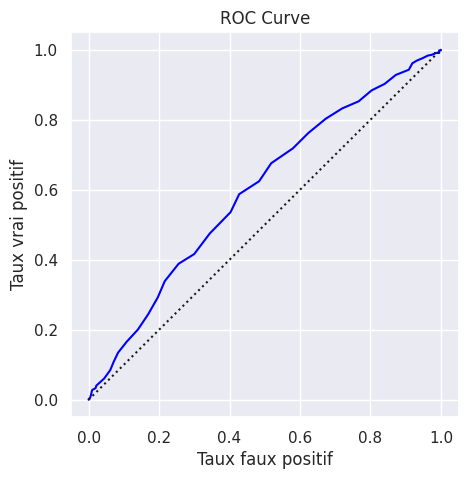

In [ ]:
plt.plot(incorrect_nondefault,correct_default,c='blue')
plt.plot(np.linspace(0,1,100),np.linspace(0,1,100),c='k',linestyle=':')
plt.title('ROC Curve')
plt.xlabel('Taux faux positif')
plt.ylabel('Taux vrai positif');

In [ ]:
xes = np.array(incorrect_nondefault[1:])-np.array(incorrect_nondefault[:-1])
area = np.sum(-xes*np.array(correct_default[:-1]))
print(area)

0.612929353260845


L'analyse de la courbe ROC avec un seuil de probabilité de 0,75 révèle que dans la population des vrais bons payeurs, seulement 0,7% ont été correctement détectés par le modèle. Bien que le modèle soit globalement significatif, le faible pourcentage de prédiction exacte suggère la nécessité d'améliorer le modèle en ajoutant d'autres variables explicatives.

In [ ]:
log_reg_age = LogisticRegression()
log_reg_age.fit(CRSC_data[['AGE']], CRSC_data['Y'])
prop_pred_proba = log_reg_age.predict_proba(CRSC_data[['AGE']])[:, 1]


## 5) Estimez un modèle LOGIT avec PROP (et une constante) comme seule variable explicative. Interprétez les résultats.

In [ ]:
logit_model = sm.Logit(CRSC_data['Y'], sm.add_constant(CRSC_data['PROP']))
logit_results = logit_model.fit()
print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.616959
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      948
Method:                           MLE   Df Model:                            1
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                 0.09651
Time:                        10:15:35   Log-Likelihood:                -586.11
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                 4.553e-29
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0614      0.073     -0.840      0.401      -0.205       0.082
PROP           2.2099      0.

Sans constante

In [ ]:

X = CRSC_data[['PROP']]
y = CRSC_data['Y']
logit_model = sm.Logit(y,X)

logit_results = logit_model.fit()
print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.617331
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      949
Method:                           MLE   Df Model:                            0
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                 0.09597
Time:                        10:15:57   Log-Likelihood:                -586.46
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PROP           2.1484      0.231      9.317      0.000       1.696       2.600


L’estimation par  maximum de vraisemblance révèle que tous les
paramètres du modèle $Y=  \beta_1 Age$ sont significatifs ; leur ‘’pvalue’’ étant
inférieure au seuil de 5%. Le coefficient de PROP étant positif et $exp(\beta_1)=13$, les plus personnes possédant leur logement seraient beaucoup moins risquées (13% plus de chances) d'être bon payeur que les locataires. Le AUC est meilleur que celui de l'Age

In [ ]:
# Calcul AUC
CRSC_data['predicted'] = logit_results.predict(CRSC_data[['PROP']])
fpr, tpr, thresholds = roc_curve(CRSC_data['Y'], CRSC_data['predicted'])
print("AUC Score:", roc_auc_score(CRSC_data['Y'], CRSC_data['predicted']))

AUC Score: 0.6399473305550654


## 6) On cherchera ensuite à obtenir un modèle où les coefficients sont significatifs (α = 10%) et où le pourcentage de bien classés est le meilleur possible (sans PROF).

### Avec NCARTES

In [ ]:
logit_model = sm.Logit(CRSC_data['Y'], sm.add_constant(CRSC_data['NCARTES']))
logit_results = logit_model.fit()
print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.585031
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      948
Method:                           MLE   Df Model:                            1
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                  0.1433
Time:                        10:17:58   Log-Likelihood:                -555.78
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                 2.515e-42
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7297      0.106     -6.866      0.000      -0.938      -0.521
NCARTES        0.4575      0.

In [ ]:
X = CRSC_data[['NCARTES']]
y = CRSC_data['Y']
logit_model = sm.Logit(y,X)

logit_results = logit_model.fit()
print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.611500
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      949
Method:                           MLE   Df Model:                            0
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                  0.1045
Time:                        10:20:03   Log-Likelihood:                -580.92
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                       nan
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
NCARTES        0.2623      0.025     10.559      0.000       0.214       0.311


In [ ]:
# Calcul AUC
CRSC_data['predicted'] = logit_results.predict(CRSC_data[['NCARTES']])
fpr, tpr, thresholds = roc_curve(CRSC_data['Y'], CRSC_data['predicted'])
print("AUC Score:", roc_auc_score(CRSC_data['Y'], CRSC_data['predicted']))

AUC Score: 0.7313722562341347


### Avec 'AGE',  'PROP', 'NCARTES'

In [ ]:
logit_model = sm.Logit(CRSC_data['Y'], sm.add_constant(CRSC_data[['AGE','PROP', 'NCARTES']]))
logit_results = logit_model.fit()
print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.514299
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      946
Method:                           MLE   Df Model:                            3
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                  0.2469
Time:                        10:21:11   Log-Likelihood:                -488.58
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                 4.066e-69
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.7060      0.441     -1.599      0.110      -1.571       0.159
AGE           -0.0128      0.

L’estimation par  maximum de vraisemblance révèle que tous les
paramètres du modèle $Y= \beta_0 + \beta_1 Age +  \beta_2 prop + \beta_1 prof$ sont significatifs sauf age et constante; leur ‘’pvalue’’ étant
inférieure au seuil de 5%. Le coefficient de AGE étant négatif et contredit les résultats trouvés ci-dessus.

In [ ]:

X = CRSC_data[['AGE','PROP', 'NCARTES']]
y = CRSC_data['Y']
logit_model = sm.Logit(y,X)

logit_results = logit_model.fit()
print(logit_results.summary())


Optimization terminated successfully.
         Current function value: 0.515653
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      947
Method:                           MLE   Df Model:                            2
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                  0.2449
Time:                        10:24:04   Log-Likelihood:                -489.87
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                 1.028e-69
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
AGE           -0.0287      0.003     -9.758      0.000      -0.034      -0.023
PROP           2.6293      0.

In [ ]:
CRSC_data['predicted'] = logit_results.predict(CRSC_data[['AGE','PROP', 'NCARTES']])
fpr, tpr, thresholds = roc_curve(CRSC_data['Y'], CRSC_data['predicted'])
print("AUC Score:", roc_auc_score(CRSC_data['Y'], CRSC_data['predicted']))

AUC Score: 0.8097904534368623


### Avec 'PROP', 'NCARTES'

In [ ]:

logit_model = sm.Logit(CRSC_data['Y'], sm.add_constant(CRSC_data[['PROP', 'NCARTES']]))
logit_results = logit_model.fit()
print(logit_results.summary())

Optimization terminated successfully.
         Current function value: 0.515124
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      947
Method:                           MLE   Df Model:                            2
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                  0.2456
Time:                        10:24:18   Log-Likelihood:                -489.37
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                 6.216e-70
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2379      0.126     -9.855      0.000      -1.484      -0.992
PROP           2.4630      0.

In [ ]:
X = CRSC_data[['PROP', 'NCARTES']]
y = CRSC_data['Y']
logit_model = sm.Logit(y,X)

logit_results = logit_model.fit()
print(logit_results.summary())


Optimization terminated successfully.
         Current function value: 0.574886
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                      Y   No. Observations:                  950
Model:                          Logit   Df Residuals:                      948
Method:                           MLE   Df Model:                            1
Date:                Mon, 03 Mar 2025   Pseudo R-squ.:                  0.1581
Time:                        10:24:23   Log-Likelihood:                -546.14
converged:                       True   LL-Null:                       -648.72
Covariance Type:            nonrobust   LLR p-value:                 1.564e-46
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
PROP           1.6712      0.237      7.037      0.000       1.206       2.137
NCARTES        0.2012      0.

### Odds ratios

In [ ]:
odds_ratios = pd.DataFrame(
    {
        "OR": logit_results.params,
        "Lower CI": logit_results.conf_int()[0],
        "Upper CI": logit_results.conf_int()[1],
    }
)
odds_ratios = np.exp(odds_ratios)

print(odds_ratios)

               OR  Lower CI  Upper CI
PROP     5.318746  3.339311  8.471524
NCARTES  1.222814  1.164400  1.284159


In [ ]:
CRSC_data['predicted'] = logit_results.predict(CRSC_data[['PROP', 'NCARTES']])
fpr, tpr, thresholds = roc_curve(CRSC_data['Y'], CRSC_data['predicted'])
print("AUC Score:", roc_auc_score(CRSC_data['Y'], CRSC_data['predicted']))

AUC Score: 0.80567056257664


Le meilleur modèle est celui avec  PROP et PROF, toutes les variables sont significatives et  l'AUC est maximal 0,81 et les signes des coefficients sont en adéquation avec les résultats trouvés dans les premières questions. Les proprietaires ont 5 fois (OR=5.3) plus de chances d'être bon payeur que les locataires



## 7) Exercice 2

Faites de même et comparez le meilleur modèle logistique avec le meilleur modèle k-NN, Naif-Bayes, LDA, QDA.